# 匯入套件

In [4]:
import numpy as np
import pandas as pd
import pickle
import os
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# 繪製列聯表

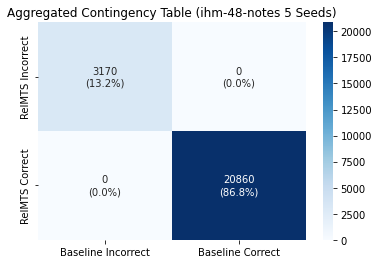

In [5]:
task = 'ihm-48-notes'
filepath1 = f"/mnt/data/yihua/master/implementations/FuseMoE/src/run/TS_Text/{task}_TS_Text_TS_mTAND_64_Text_mTAND_64_layer1_moe_['laplace']_joint_[16, 5]_top_[4, 4]_batch_0.0004_8_8_128_1_2_512"
filepath2 = f"/mnt/data/yihua/master/implementations/FuseMoE/src/run/TS_Text/{task}_TS_Text_TS_mTAND_64_Text_mTAND_64_layer1_moe_['laplace']_joint_[16, 5]_top_[4, 4]_batch_0.0004_8_8_128_1_2_512"

with open(os.path.join(filepath1, 'sample_result.pkl'), 'rb') as f:
    result1 = pickle.load(f)

with open(os.path.join(filepath2, 'sample_result.pkl'), 'rb') as f:
    result2 = pickle.load(f)

correct_a = (result1['preds'].flatten() == result1['labels'].flatten()).astype(int)
correct_b = (result2['preds'].flatten() == result2['labels'].flatten()).astype(int)

tn, fp, fn, tp = confusion_matrix(correct_a, correct_b, labels=[0, 1]).ravel()
total_contingency = np.array([[tn, fp], [fn, tp]])

ct_df = pd.DataFrame(total_contingency, 
                     index=['ReIMTS Incorrect', 'ReIMTS Correct'],
                     columns=['Baseline Incorrect', 'Baseline Correct'])

total = total_contingency.sum()
percentages = total_contingency / total * 100

annot_labels = np.array([
    [f"{val}\n({pct:.1f}%)" for val, pct in zip(row_val, row_pct)]
    for row_val, row_pct in zip(total_contingency, percentages)
])

os.makedirs('./images', exist_ok=True)
sns.heatmap(ct_df, annot=annot_labels, fmt='', cmap='Blues')
plt.title(f'Aggregated Contingency Table ({task} 5 Seeds)')
plt.savefig(f'./images/contigency_table_{task}.png')
plt.show()
plt.close()